# Random Forest — Network Intrusion Detection

Huấn luyện và đánh giá mô hình **Random Forest** trên tập dữ liệu CICIDS2017.

In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

# Thêm thư mục gốc dự án vào sys.path
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_splits,
    evaluate_model,
    plot_confusion_matrix,
    compare_models,
)

In [2]:
# --- STEP 1: Load dữ liệu đã chia sẵn ---
print("=" * 70)
print("STEP 1: Loading pre-split data")
print("=" * 70)

X_train, X_test, y_train, y_test = load_splits()

print(f"Feature columns: {X_train.shape[1]}")
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading pre-split data
Loaded splits from disk.
Feature columns: 52
Train size: 2,016,609  |  Test size: 504,153
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'PortScan', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# --- STEP 2: Train Random Forest ---
print("\n" + "=" * 70)
print("STEP 2: Training Random Forest (n_estimators=300)")
print("=" * 70)

t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("\nTraining model...")
rf_model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"\nTraining completed in {train_time:.2f} seconds")


STEP 2: Training Random Forest (n_estimators=300)

Training model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  8.8min



Training completed in 719.44 seconds


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 11.7min finished


In [4]:
# --- STEP 3: Evaluate ---
print("\n" + "=" * 70)
print("STEP 3: Model Evaluation")
print("=" * 70)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

rf_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name="Random Forest (n_estimators=300)",
    y_pred_proba=y_pred_proba,
    labels=rf_model.classes_.tolist(),
)

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.



STEP 3: Model Evaluation


[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.0s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    1.6s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.9s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    1.5s finished



  Random Forest (n_estimators=300) — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.89      0.76      0.82       390
               Brute Force       1.00      1.00      1.00      1830
                      DDoS       1.00      1.00      1.00     25603
                       DoS       1.00      1.00      1.00     38749
                Heartbleed       1.00      1.00      1.00         2
                  PortScan       0.99      0.99      0.99     18139
  Web Attack � Brute Force       0.74      0.81      0.77       294
Web Attack � Sql Injection       0.50      0.25      0.33         4
          Web Attack � XSS       0.43      0.31      0.36       130

                  accuracy                           1.00    504153
                 macro avg       0.85      0.81      0.83    504153
              weighted avg       1.00      1.00      1.00


STEP 4: Confusion Matrix


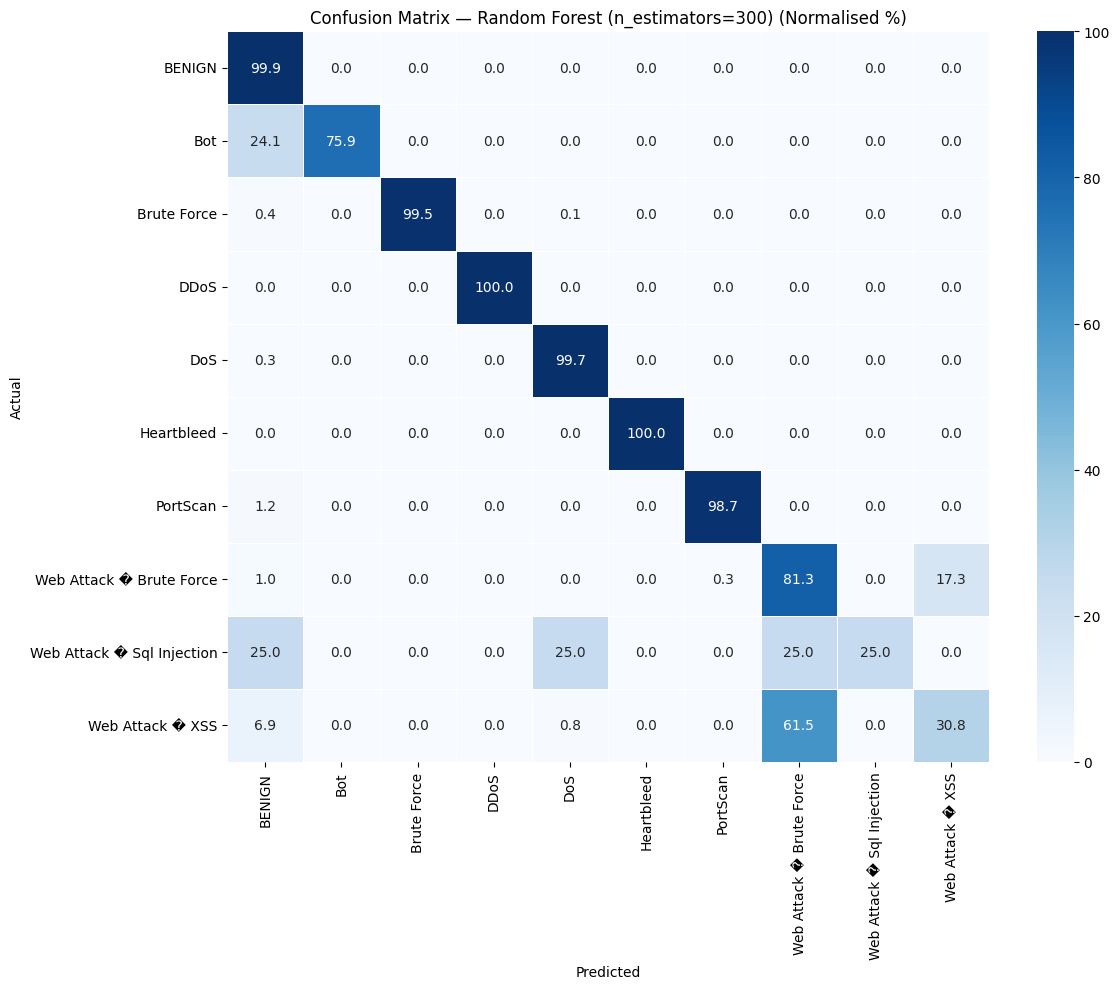

In [5]:
# --- STEP 4: Confusion Matrix ---
print("\n" + "=" * 70)
print("STEP 4: Confusion Matrix")
print("=" * 70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=rf_model.classes_.tolist(),
    model_name="Random Forest (n_estimators=300)",
    normalize=True,
    figsize=(12, 10),
)


STEP 5: Feature Importance (Top 20)
                    Feature  Importance
      Bwd Packet Length Std    0.076445
     Packet Length Variance    0.068593
          Packet Length Std    0.066195
      Bwd Packet Length Max    0.050954
     Bwd Packet Length Mean    0.047449
        Average Packet Size    0.046463
Total Length of Fwd Packets    0.046018
          Subflow Fwd Bytes    0.042772
          Max Packet Length    0.036106
      Fwd Packet Length Max    0.032600
         Packet Length Mean    0.031410
                Fwd IAT Std    0.025904
           Destination Port    0.025126
          Total Fwd Packets    0.024443
           act_data_pkt_fwd    0.022851
    Init_Win_bytes_backward    0.021661
          Bwd Header Length    0.020751
     Fwd Packet Length Mean    0.018695
               Flow IAT Max    0.018129
      Fwd Packet Length Std    0.017699


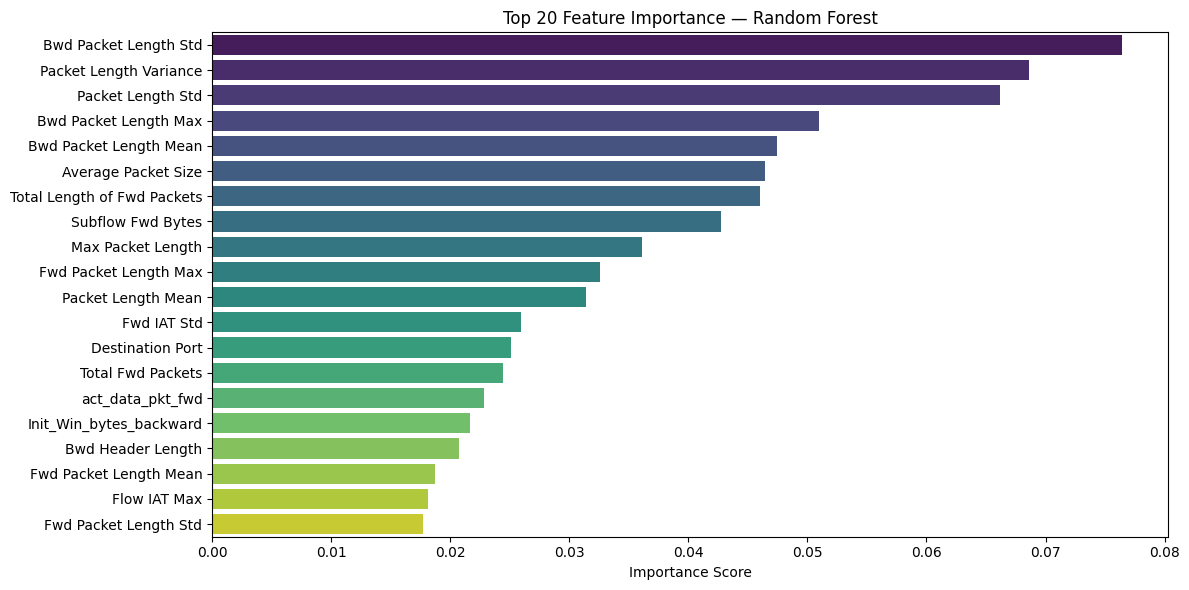

In [6]:
# --- STEP 5: Feature Importance ---
print("\n" + "=" * 70)
print("STEP 5: Feature Importance (Top 20)")
print("=" * 70)

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_imp.head(20),
    x="Importance", y="Feature",
    hue="Feature", legend=False,
    palette="viridis",
)
plt.title("Top 20 Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [7]:
# --- STEP 6: Summary ---
print("\n" + "=" * 70)
print("STEP 6: Summary")
print("=" * 70)

comparison_df = compare_models([rf_results])
print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

print(f"\nTraining time  : {train_time:.2f}s")
print(f"Test set size  : {len(y_test):,}")
print(f"Estimators     : 300")
print(f"Features       : {X_train.shape[1]}")
print(f"Classes        : {len(rf_model.classes_)}")


STEP 6: Summary

Performance Metrics:
                           Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Random Forest (n_estimators=300)    0.9982                0.9981             0.8547             0.9982          0.8108         0.9982      0.8268       0.9939 0.9939              0.9998           0.9866

Training time  : 719.44s
Test set size  : 504,153
Estimators     : 300
Features       : 52
Classes        : 10
